<a href="https://colab.research.google.com/github/exdsgift/NerGuard/blob/main/PII_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing the modules

In [2]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"

In [3]:
# !pip install -q "transformers>=4.40" datasets seqeval accelerate

import torch
import os, json, unicodedata
from datasets import load_dataset, DatasetDict
import numpy as np
from typing import List, Dict, Tuple
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
from seqeval.metrics import f1_score, classification_report
from seqeval.scheme import IOB2
import pprint as pp

2025-11-08 17:21:26.844137: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Specifying CUDA as the device for torch

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
!nvidia-smi

Sat Nov  8 17:21:29 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.230.02             Driver Version: 535.230.02   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Quadro RTX 6000                On  | 00000000:19:00.0 Off |                  Off |
| 33%   47C    P8              32W / 260W |   9415MiB / 24576MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

# Loading dataset

In [5]:
ds = load_dataset("gretelai/synthetic_pii_finance_multilingual")
print(ds)

DatasetDict({
    train: Dataset({
        features: ['level_0', 'index', 'document_type', 'document_description', 'expanded_type', 'expanded_description', 'language', 'language_description', 'domain', 'generated_text', 'pii_spans', 'conformance_score', 'quality_score', 'toxicity_score', 'bias_score', 'groundedness_score'],
        num_rows: 50346
    })
    test: Dataset({
        features: ['level_0', 'index', 'document_type', 'document_description', 'expanded_type', 'expanded_description', 'language', 'language_description', 'domain', 'generated_text', 'pii_spans', 'conformance_score', 'quality_score', 'toxicity_score', 'bias_score', 'groundedness_score'],
        num_rows: 5594
    })
})


In [6]:
if "validation" not in ds:
    tmp = ds["train"].train_test_split(test_size=0.06, seed=42)
    ds = DatasetDict(
        {"train": tmp["train"], "validation": tmp["test"], "test": ds["test"]}
    )
print(ds)

DatasetDict({
    train: Dataset({
        features: ['level_0', 'index', 'document_type', 'document_description', 'expanded_type', 'expanded_description', 'language', 'language_description', 'domain', 'generated_text', 'pii_spans', 'conformance_score', 'quality_score', 'toxicity_score', 'bias_score', 'groundedness_score'],
        num_rows: 47325
    })
    validation: Dataset({
        features: ['level_0', 'index', 'document_type', 'document_description', 'expanded_type', 'expanded_description', 'language', 'language_description', 'domain', 'generated_text', 'pii_spans', 'conformance_score', 'quality_score', 'toxicity_score', 'bias_score', 'groundedness_score'],
        num_rows: 3021
    })
    test: Dataset({
        features: ['level_0', 'index', 'document_type', 'document_description', 'expanded_type', 'expanded_description', 'language', 'language_description', 'domain', 'generated_text', 'pii_spans', 'conformance_score', 'quality_score', 'toxicity_score', 'bias_score', 'grounde

In [7]:
ds.shape

{'train': (47325, 16), 'validation': (3021, 16), 'test': (5594, 16)}

In [8]:
df = ds["train"].to_pandas()
df.head()

,level_0,index,document_type,document_description,expanded_type,expanded_description,language,language_description,domain,generated_text,pii_spans,conformance_score,quality_score,toxicity_score,bias_score,groundedness_score
0,25744,25744,IT support ticket,A record of a reported technical issue or requ...,None,Describe the steps to troubleshoot the printer...,English,English language as spoken in the United Kingdom,finance,IT Support Ticket:\n\nTicket ID: 002784\nDate/...,"[{""start"": 58, ""end"": 77, ""label"": ""date_time""...",85,90,5,15,95
1,22122,22122,Financial Risk Assessment,A document evaluating potential financial risk...,Financial Performance Review,Conduct a comprehensive review of the business...,English,English language as spoken in the United Kingdom,finance,Financial Risk Assessment: Financial Performan...,"[{""start"": 158, ""end"": 183, ""label"": ""company""...",85,90,5,10,95
2,31483,31483,XBRL,"A structured, electronic format for business a...",Custom XBRL Schema,"To create a custom XBRL schema, first, define ...",Swedish,Swedish language as spoken in Sweden,finance,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<xsd:s...",[],95,90,5,10,100
3,45476,45476,Financial Statement,A formal record of the financial activities an...,Public Disclosure,"Release financial information to the public, e...",English,English language as spoken in the United State...,finance,FINANCIAL STATEMENT\n\nPublic Disclosure\n\nFo...,"[{""start"": 935, ""end"": 945, ""label"": ""employee...",85,90,5,10,95
4,4417,4417,Bill of Lading,A document issued by a carrier to acknowledge ...,Negotiable Bill of Lading,"For a Negotiable Bill of Lading, obtain compre...",France,French language as spoken in France,finance,CONNAISSEMENT DE MARCHANDISES\n\nNo. de connai...,"[{""start"": 104, ""end"": 116, ""label"": ""name""}, ...",85,90,5,20,80


# Activating the mdeberta-v3-base tokenizer (fast) and support functions

In [9]:
try:
    tok = AutoTokenizer.from_pretrained("microsoft/mdeberta-v3-base", use_fast=True)
    assert tok.is_fast, "Serve tokenizer fast per offset_mapping"
except Exception as e:
    print("An error occurred while downloading the tokenizer.")
    print(str(e))
    import traceback

    print(traceback.format_exc())

/home/gabriele/Github/NerGuard/.venv/lib/python3.11/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [10]:
def parse_spans(spans):
    if isinstance(spans, str):
        try:
            spans = json.loads(spans)
        except json.JSONDecodeError:
            return []
    if not isinstance(spans, list):
        return []
    out = []
    for s in spans:
        if isinstance(s, dict) and all(k in s for k in ("start", "end", "label")):
            out.append(s)
    return out

In [11]:
def collect_label_set(dataset_dict):
    labels = set()
    for split in dataset_dict.keys():
        for ex in dataset_dict[split]:
            for s in parse_spans(ex["pii_spans"]):
                labels.add(s["label"])
    return sorted(labels)


entity_labels = collect_label_set(
    ds
)  # es: ['company','date','name','street_address', ...]
bio_labels = (
    ["O"] + [f"B-{l}" for l in entity_labels] + [f"I-{l}" for l in entity_labels]
)
label2id = {l: i for i, l in enumerate(bio_labels)}
id2label = {i: l for l, i in label2id.items()}

In [12]:
bio_labels

['O',
 'B-account_pin',
 'B-api_key',
 'B-bank_routing_number',
 'B-bban',
 'B-company',
 'B-credit_card_number',
 'B-credit_card_security_code',
 'B-customer_id',
 'B-date',
 'B-date_of_birth',
 'B-date_time',
 'B-driver_license_number',
 'B-email',
 'B-employee_id',
 'B-first_name',
 'B-iban',
 'B-ipv4',
 'B-ipv6',
 'B-last_name',
 'B-local_latlng',
 'B-name',
 'B-passport_number',
 'B-password',
 'B-phone_number',
 'B-ssn',
 'B-street_address',
 'B-swift_bic_code',
 'B-time',
 'B-user_name',
 'I-account_pin',
 'I-api_key',
 'I-bank_routing_number',
 'I-bban',
 'I-company',
 'I-credit_card_number',
 'I-credit_card_security_code',
 'I-customer_id',
 'I-date',
 'I-date_of_birth',
 'I-date_time',
 'I-driver_license_number',
 'I-email',
 'I-employee_id',
 'I-first_name',
 'I-iban',
 'I-ipv4',
 'I-ipv6',
 'I-last_name',
 'I-local_latlng',
 'I-name',
 'I-passport_number',
 'I-password',
 'I-phone_number',
 'I-ssn',
 'I-street_address',
 'I-swift_bic_code',
 'I-time',
 'I-user_name']

spans → BIO with offset_mapping

In [13]:
def spans_to_bio(text, spans, label2id, tokenizer, max_length=256):
    import unicodedata

    text = unicodedata.normalize("NFC", text)
    spans = parse_spans(spans)

    # 1) maschera char-level
    char_tags = ["O"] * len(text)
    for s in spans:
        start, end, lab = s.get("start"), s.get("end"), s.get("label")
        if (
            not isinstance(start, int)
            or not isinstance(end, int)
            or not isinstance(lab, str)
        ):
            continue
        if start < 0 or end <= start or end > len(text):
            continue
        if f"B-{lab}" not in label2id or f"I-{lab}" not in label2id:
            continue
        char_tags[start] = f"B-{lab}"
        for i in range(start + 1, end):
            char_tags[i] = f"I-{lab}"

    # 2) tokenizza con special e offsets
    enc = tokenizer(
        text,
        return_offsets_mapping=True,
        return_attention_mask=True,
        add_special_tokens=True,  # <-- importante
        truncation=True,
        max_length=max_length,
    )
    offsets = enc["offset_mapping"]

    tags = []
    for a, b in offsets:
        if a == 0 and b == 0:
            tags.append(None)  # special token -> ignora in loss
            continue
        if a == b:
            tags.append("O")
            continue
        start_tag = char_tags[a] if 0 <= a < len(text) else "O"
        if start_tag.startswith("B-"):
            lab = start_tag
        else:
            window = [t for t in char_tags[a:b] if t != "O"]
            if window:
                any_lab = window[0]
                lab = "I-" + any_lab.split("-", 1)[1]
            else:
                lab = "O"
        tags.append(lab)

    ignore_index = -100
    label_ids = [ignore_index if t is None else label2id[t] for t in tags]
    return enc["input_ids"], enc["attention_mask"], label_ids


Processing all splits

In [14]:
from transformers import DataCollatorForTokenClassification

TEXT_COL = "generated_text"
SPAN_COL = "pii_spans"


def preprocess_batch(batch):
    input_ids, attention_mask, labels = [], [], []
    for text, spans in zip(batch[TEXT_COL], batch[SPAN_COL]):
        ids, mask, y = spans_to_bio(text, spans, label2id, tok, max_length=256)
        input_ids.append(ids)
        attention_mask.append(mask)
        labels.append(y)
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


remove_cols = list(ds["train"].column_names)
processed = DatasetDict()
for split in ds.keys():
    processed[split] = (
        ds[split]
        .map(preprocess_batch, batched=True, remove_columns=remove_cols)
        .with_format(
            "torch", columns=["input_ids", "attention_mask"], output_all_columns=True
        )
    )

# .with_format("torch", columns=["input_ids","attention_mask","labels"])
train_processed = processed["train"]
val_processed = processed["validation"]

data_collator = DataCollatorForTokenClassification(
    tokenizer=tok, padding=True, label_pad_token_id=-100
)

Map:   0%|          | 0/5594 [00:00<?, ? examples/s]

In [15]:
ds = train_processed.to_pandas()
ds.head(3)

,input_ids,attention_mask,labels
0,"[1, 6938, 14941, 87709, 268, 87709, 2531, 268,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[1, 260, 30091, 57855, 260, 103767, 268, 260, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,"[1, 1043, 292, 11395, 7061, 888, 19655, 312, 2...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [16]:
print(train_processed[0])

{'input_ids': tensor([     1,   6938,  14941,  87709,    268,  87709,   2531,    268,  59206,
         49001,   7301,    276,  16887,  12882,    346,    268, 163634, 233194,
          6160,  47967,    429,   1189,  88205,   9462,    268,  17777,    260,
         69316, 101608,    858,   1341,  92820,    276,  33984,    268,  66005,
           275,  11297,    562,    411,    268,   5528,    339, 206311,  87906,
           272,  87709,  12629,    268,    260,  45312,  46161,    260, 138452,
           268,  40748,  35796,    268,   7071,  19467,    268,  17777,    260,
         69316, 101608,    858,   1341,    703, 122306, 158486,    273,  67145,
           262,  10464,    369,  54747,    260,  39510,    260,    263,    260,
         32946,  13798,    515,    288,  63185,    260,  15772,    345,    288,
           260, 187565, 163433,    346,    337,  13978,    411,  14131,    261,
           487,  63185,    260,  15485,    264,    289,    391,   1315,   1047,
           348,    261,   

In [17]:
from pprint import pprint

print("num_labels:", len(label2id))
pprint(label2id)  # label string -> id
# If you also want the reverse:
id2label = {i: l for l, i in label2id.items()}


num_labels: 59
{'B-account_pin': 1,
 'B-api_key': 2,
 'B-bank_routing_number': 3,
 'B-bban': 4,
 'B-company': 5,
 'B-credit_card_number': 6,
 'B-credit_card_security_code': 7,
 'B-customer_id': 8,
 'B-date': 9,
 'B-date_of_birth': 10,
 'B-date_time': 11,
 'B-driver_license_number': 12,
 'B-email': 13,
 'B-employee_id': 14,
 'B-first_name': 15,
 'B-iban': 16,
 'B-ipv4': 17,
 'B-ipv6': 18,
 'B-last_name': 19,
 'B-local_latlng': 20,
 'B-name': 21,
 'B-passport_number': 22,
 'B-password': 23,
 'B-phone_number': 24,
 'B-ssn': 25,
 'B-street_address': 26,
 'B-swift_bic_code': 27,
 'B-time': 28,
 'B-user_name': 29,
 'I-account_pin': 30,
 'I-api_key': 31,
 'I-bank_routing_number': 32,
 'I-bban': 33,
 'I-company': 34,
 'I-credit_card_number': 35,
 'I-credit_card_security_code': 36,
 'I-customer_id': 37,
 'I-date': 38,
 'I-date_of_birth': 39,
 'I-date_time': 40,
 'I-driver_license_number': 41,
 'I-email': 42,
 'I-employee_id': 43,
 'I-first_name': 44,
 'I-iban': 45,
 'I-ipv4': 46,
 'I-ipv6': 47,

In [18]:
# take one example from the processed train set
ex = train_processed[0]

tokens = tok.convert_ids_to_tokens(ex["input_ids"])
tag_ids = ex["labels"]
tag_str = [id2label[int(i)] for i in tag_ids if i != -100]
aligned_data = [
    (tokens[i], tag_ids[i], id2label[int(tag_ids[i])])
    for i in range(len(tokens))
    if tag_ids[i] != -100
]

for t, tid, ts in aligned_data:
    print(f"{t:20s}  {tid:3d}  {ts}")

▁IT                     0  O
▁Support                0  O
▁Ticket                 0  O
:                       0  O
▁Ticket                 0  O
▁ID                     0  O
:                       0  O
▁002                    0  O
784                     0  O
▁Date                   0  O
/                       0  O
Time                    0  O
▁Report                 0  O
ed                      0  O
:                       0  O
▁08/2                  40  I-date_time
6/19                   40  I-date_time
74                     40  I-date_time
▁03:0                  40  I-date_time
5                      40  I-date_time
▁PM                    40  I-date_time
▁Reporter               0  O
▁Name                   0  O
:                       0  O
▁Alex                  50  I-name
▁                      50  I-name
Catherine              50  I-name
▁Chau                  50  I-name
ve                     50  I-name
au                     50  I-name
▁Device                 0  O
/          

# Selecting a batch size and creating an iterator

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from keras.utils import pad_sequences
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertConfig
from torch.optim import AdamW
from transformers.optimization import get_linear_schedule_with_warmup
from transformers import BertForSequenceClassification
from tqdm import tqdm, trange  # for progress bars
import pandas as pd
import io
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image  # for image rendering

In [20]:
train_processed

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 47325
})

In [21]:
# Select a batch size for training. For fine-tuning BERT on a specific task, the authors recommend a batch size of 16 or 32
batch_size = 32

# Create an iterator of our data with torch DataLoader. This helps save on memory during training because, unlike a for loop,
# with an iterator the entire dataset does not need to be loaded into memory

# train_data = TensorDataset(train_processed['input_ids'], train_processed['attention_mask'], train_processed['labels'])
train_sampler = RandomSampler(train_processed)
train_dataloader = DataLoader(
    train_processed,
    sampler=train_sampler,
    batch_size=batch_size,
    collate_fn=data_collator,
)

# validation_data = TensorDataset(val_processed)
validation_sampler = SequentialSampler(val_processed)
validation_dataloader = DataLoader(
    val_processed,
    sampler=validation_sampler,
    batch_size=batch_size,
    collate_fn=data_collator,
)

In [22]:
# Initializing a BERT bert-base-uncased style configuration
from transformers import AutoConfig, AutoModel

model_name = "microsoft/deberta-v3-base"

configuration = AutoConfig.from_pretrained(model_name)

# Initializing a model from the bert-base-uncased style configuration
model = AutoModel.from_pretrained(model_name, config=configuration)

# Accessing the model configuration
# configuration = model.config
print(configuration)

DebertaV2Config {
  "attention_probs_dropout_prob": 0.1,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-07,
  "legacy": true,
  "max_position_embeddings": 512,
  "max_relative_positions": -1,
  "model_type": "deberta-v2",
  "norm_rel_ebd": "layer_norm",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_dropout": 0,
  "pooler_hidden_act": "gelu",
  "pooler_hidden_size": 768,
  "pos_att_type": [
    "p2c",
    "c2p"
  ],
  "position_biased_input": false,
  "position_buckets": 256,
  "relative_attention": true,
  "share_att_key": true,
  "transformers_version": "4.57.0",
  "type_vocab_size": 0,
  "vocab_size": 128100
}



In [23]:
# @title
from collections import Counter

used_ids = Counter()
for example in train_processed:
    used_ids.update(i for i in example["labels"] if i != -100)  # ignore masked

print("Unique label IDs used:", len(used_ids))
for lid, cnt in used_ids.most_common()[:30]:
    print(f"{lid:3d}  {id2label[lid]:30s}  {cnt}")

Unique label IDs used: 59
  0  O                               9965295
 50  I-name                          263409
 55  I-street_address                253861
 34  I-company                       166722
 38  I-date                          160439
 42  I-email                         69160
 53  I-phone_number                  30451
 57  I-time                          26767
 21  B-name                          22320
 47  I-ipv6                          19143
  5  B-company                       17193
 31  I-api_key                       16145
 45  I-iban                          10995
 26  B-street_address                8741
 13  B-email                         7114
  9  B-date                          7017
 33  I-bban                          6750
 56  I-swift_bic_code                6546
 37  I-customer_id                   6522
 39  I-date_of_birth                 5771
 52  I-password                      5284
 49  I-local_latlng                  5062
 35  I-credit_card_number      

In [24]:
model = AutoModelForTokenClassification.from_pretrained(
    "microsoft/mdeberta-v3-base",
    num_labels=len(bio_labels),
    id2label=id2label,
    label2id=label2id,
)

Some weights of DebertaV2ForTokenClassification were not initialized from the model checkpoint at microsoft/mdeberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [25]:
# RESIZE embeddings per matchare il tokenizer
print(f"Original vocab size: {model.config.vocab_size}")
model.resize_token_embeddings(len(tok))
print(f"Resized to: {model.config.vocab_size}")
print(f"Embeddings shape: {model.deberta.embeddings.word_embeddings.num_embeddings}")

Original vocab size: 251000
Resized to: 250102
Embeddings shape: 250102


In [26]:
model = nn.DataParallel(model, device_ids=[0, 1])
model = model.to(device)

In [27]:
# Test con un batch su GPU
print("\n🧪 Testing forward pass...")
test_batch = next(iter(train_dataloader))

try:
    # Sposta su GPU
    test_input = test_batch["input_ids"][:2].to(device)
    test_mask = test_batch["attention_mask"][:2].to(device)
    test_labels = test_batch["labels"][:2].to(device)

    # Forward pass
    with torch.no_grad():
        outputs = model(test_input, attention_mask=test_mask, labels=test_labels)

    print("✓ Forward pass successful!")
    print(f"  Loss: {outputs.loss.mean().item():.4f}")
    print(f"  Logits shape: {outputs.logits.shape}")
    print(f"  Loss per GPU: {outputs.loss}")

except Exception as e:
    print(f"✗ Error: {e}")
    import traceback

    traceback.print_exc()


🧪 Testing forward pass...
✓ Forward pass successful!
  Loss: 3.8917
  Logits shape: torch.Size([2, 256, 59])
  Loss per GPU: tensor([3.9151, 3.8682], device='cuda:0')


/home/gabriele/Github/NerGuard/.venv/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


In [28]:
# Parametri ottimizzati per DaBERTa v3 su task di NER/PII detection
param_optimizer = list(model.named_parameters())

# Non applicare weight decay a bias e LayerNorm
no_decay = ["bias", "LayerNorm.weight", "LayerNorm.bias"]

optimizer_grouped_parameters = [
    {
        "params": [
            p for n, p in param_optimizer if not any(nd in n for nd in no_decay)
        ],
        "weight_decay": 0.01,  # Valore tipico per DaBERTa (0.01-0.1)
    },
    {
        "params": [p for n, p in param_optimizer if any(nd in n for nd in no_decay)],
        "weight_decay": 0.0,
    },
]

In [29]:
# Displaying a sample of the parameter_optimizer:  layer 3
layer_parameters = [p for n, p in model.named_parameters() if "layer.3" in n]

In [30]:
# Displaying names of parameters for which weight decay is not applied
no_decay

['bias', 'LayerNorm.weight', 'LayerNorm.bias']

In [31]:
# Displaying the list of the two dictionaries
small_sample = [
    {
        "params": [
            p for n, p in param_optimizer if not any(nd in n for nd in no_decay)
        ][:2],
        "weight_decay_rate": 0.01,
    },
    {
        "params": [p for n, p in param_optimizer if any(nd in n for nd in no_decay)][
            :2
        ],
        "weight_decay_rate": 0.0,
    },
]

for i, group in enumerate(small_sample):
    print(f"Group {i + 1}:")
    print(f"Weight decay rate: {group['weight_decay_rate']}")
    for j, param in enumerate(group["params"]):
        print(f"Parameter {j + 1}: {param}")

Group 1:
Weight decay rate: 0.01
Parameter 1: Parameter containing:
tensor([[ 0.0187, -0.0047, -0.0024,  ..., -0.0198,  0.0154,  0.0246],
        [-0.0253, -0.0084, -0.0109,  ..., -0.0201, -0.0056, -0.0047],
        [-0.0233, -0.0060, -0.0109,  ..., -0.0165, -0.0049, -0.0019],
        ...,
        [ 0.0183, -0.0022, -0.0049,  ..., -0.0109,  0.0163,  0.0164],
        [ 0.0156,  0.0029, -0.0050,  ..., -0.0215,  0.0150,  0.0230],
        [-0.0560,  0.0241,  0.0872,  ...,  0.0065, -0.0975,  0.0826]],
       device='cuda:0', requires_grad=True)
Parameter 2: Parameter containing:
tensor([[ 0.0612, -0.1571,  0.1099,  ...,  0.0766, -0.1010, -0.0101],
        [-0.0350,  0.2230,  0.1971,  ...,  0.0668,  0.1351, -0.0952],
        [ 0.0621,  0.1041,  0.1530,  ..., -0.2688, -0.0279, -0.0012],
        ...,
        [ 0.2539,  0.0209,  0.0380,  ...,  0.1475,  0.0853,  0.0164],
        [-0.1096,  0.1230,  0.1782,  ...,  0.0779, -0.0202,  0.0695],
        [-0.1597,  0.1494,  0.2402,  ...,  0.1786, -0.02

# The hyperparameters for the training loop

In [32]:
# Number of training epochs (authors recommend between 2 and 4)
epochs = 4

optimizer = AdamW(
    optimizer_grouped_parameters,
    lr=2e-5,  # args.learning_rate - default range: 1e-5 a 5e-5
    eps=1e-8,  # args.adam_epsilon  - default is 1e-8.
)
# Total number of training steps is number of batches * number of epochs.
# `train_dataloader` contains batched data so `len(train_dataloader)` gives
# us the number of batches.
total_steps = len(train_dataloader) * epochs

# Create the learning rate scheduler.
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,  # Default value in run_glue.py
    num_training_steps=total_steps,
)

In [33]:
# Creating the Accuracy Measurement Function
# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)


def compute_metrics(preds, labels, label_list):
    """
    Metrics for PII detection (precision, recall, F1)
    """
    pred_flat = np.argmax(preds, axis=2).flatten()
    labels_flat = labels.flatten()

    # Rimuovi i padding tokens (assumendo che -100 sia usato per padding)
    mask = labels_flat != -100
    pred_flat = pred_flat[mask]
    labels_flat = labels_flat[mask]

    # F1 score (più importante dell'accuracy per PII detection!)
    f1 = f1_score(labels_flat, pred_flat, average="weighted")
    accuracy = np.sum(pred_flat == labels_flat) / len(labels_flat)

    return {"accuracy": accuracy, "f1": f1}

# training loop

In [34]:
# Diagnostic test
print("Checking data integrity...")

# Check a sample batch
sample_batch = next(iter(train_dataloader))
print(f"Batch keys: {sample_batch.keys()}")
print(f"Input IDs shape: {sample_batch['input_ids'].shape}")
print(f"Labels shape: {sample_batch['labels'].shape}")

# Check label range
all_labels = []
for batch in train_dataloader:
    labels = batch["labels"].numpy()
    # Ignore padding (-100)
    valid_labels = labels[labels != -100]
    all_labels.extend(valid_labels.tolist())

all_labels = np.array(all_labels)
print(f"\nLabel Statistics:")
print(f"  Min label: {all_labels.min()}")
print(f"  Max label: {all_labels.max()}")
print(f"  Unique labels: {np.unique(all_labels)}")
print(f"  Model num_labels: {len(label2id)}")

# Check if labels are in valid range
if all_labels.max() >= len(label2id):
    print(f"\n⚠️ ERROR: Max label ({all_labels.max()}) >= num_labels ({len(label2id)})")
    print("Your labels are out of range!")
if all_labels.min() < 0:
    print(
        f"\n⚠️ WARNING: Found negative labels other than -100: {all_labels[all_labels < 0]}"
    )

print("=" * 50 + "\n")

Checking data integrity...
Batch keys: KeysView({'input_ids': tensor([[     1, 228825,  80358,  ...,    456,  26190,      2],
        [     1,  68313,   7702,  ...,  32142,  91521,      2],
        [     1,  26222,    260,  ...,  22023,    304,      2],
        ...,
        [     1,   3094,   8669,  ...,   8669,   8669,      2],
        [     1,   1043,    292,  ...,    268,  15404,      2],
        [     1,    260, 116584,  ...,    282,    715,      2]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]]), 'labels': tensor([[-100,    0,    0,  ...,    0,    0, -100],
        [-100,    0,    0,  ...,    0,    0, -100],
        [-100,    0,    0,  ...,    0,    0, -100],
        ...,
        [-100,    0,    0,  ...,    0,    0, -100],
        [-100,    0,    0,  ...,    0,    0, -100],
        [-100,    0

In [35]:
def estimate_gpu_memory(model, batch_size, seq_length, num_labels):
    # Model params
    num_params = sum(p.numel() for p in model.parameters())
    # FP32 = 4 bytes per params (GB)
    model_memory = (num_params * 4) / (1024**3)
    # Gradients (same dimension as params)
    gradient_memory = model_memory
    # Oprimizer state (Adam = 2x params)
    optimizer_memory = model_memory * 2

    # DaBERTa: ~12 * num_layers * batch_size * seq_length * hidden_size * 4 bytes
    hidden_size = model.module.config.hidden_size  # Access config through .module
    num_layers = model.module.config.num_hidden_layers  # Access config through .module
    activation_memory = (
        12 * num_layers * batch_size * seq_length * hidden_size * 4
    ) / (1024**3)

    total = model_memory + gradient_memory + optimizer_memory + activation_memory

    print("GPU MEMORY ESTIMATION (approximate)")
    print("=" * 60)
    print(f"Model:                  {model_memory:.2f} GB")
    print(f"Gradients:              {gradient_memory:.2f} GB")
    print(f"Optimizer (Adam):       {optimizer_memory:.2f} GB")
    print(f"Activations (forward):  {activation_memory:.2f} GB")
    print("_" * 60)
    print(f"Total:                  {total:.2f} GB\n")
    print(f"Batch size:             {batch_size}")
    print(f"Sequence length:        {seq_length}")
    print(f"Total params:           {num_params:,}")
    print("_" * 60)


estimate_gpu_memory(
    model,
    batch_size=16,
    seq_length=512,
    num_labels=len(label2id),
)

GPU MEMORY ESTIMATION (approximate)
Model:                  1.03 GB
Gradients:              1.03 GB
Optimizer (Adam):       2.07 GB
Activations (forward):  3.38 GB
____________________________________________________________
Total:                  7.51 GB

Batch size:             16
Sequence length:        512
Total params:           277,574,459
____________________________________________________________


# Training Eval

In [36]:
def compute_metrics(preds, labels):
    pred_flat = np.argmax(preds, axis=2).flatten()
    labels_flat = labels.flatten()

    # No padding
    mask = labels_flat != -100
    pred_flat = pred_flat[mask]
    labels_flat = labels_flat[mask]

    f1 = f1_score(labels_flat, pred_flat, average="weighted", zero_division=0)
    accuracy = np.sum(pred_flat == labels_flat) / len(labels_flat)

    return {"accuracy": accuracy, "f1": f1}

In [39]:
from sklearn.metrics import f1_score
import numpy as np
import torch
from tqdm import trange
import datetime, os
import time

today = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = f"models/dabertav3_{today}"
os.makedirs(save_dir, exist_ok=True)

base = model.module if hasattr(model, "module") else model

# Store metriche
history = {
    'train_loss': [],
    'val_loss': [],
    'learning_rates': [],
    'epoch_times': [],
    'best_epoch': 0,
    'val_f1': []
}

best_val_loss = float("inf")
train_loss_set = []

# Training loop
for epoch in range(epochs):
    epoch_start = time.time()

    model.train()
    tr_loss = 0
    nb_tr_steps = 0
    train_batch_losses = []

    for step, batch in enumerate(train_dataloader):
        b_input_ids = batch["input_ids"].to(device)
        b_input_mask = batch["attention_mask"].to(device)
        b_labels = batch["labels"].to(device)

        # Zero gradients
        optimizer.zero_grad()
        # Forward pass
        outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss.mean() if outputs.loss.dim() > 0 else outputs.loss
        # Backward pass
        loss.backward()
        # Gradient clipping (!!!!!)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update
        optimizer.step()
        scheduler.step()

        # Tracking
        tr_loss += loss.item()
        nb_tr_steps += 1
        train_batch_losses.append(loss.item())

        if step % 100 == 0 and step > 0:  # print every 10 steps
            print(
                f"epoch: {epoch + 1}      step: {step:5d}     loss: {loss.item():.4f}"
            )

    avg_train_loss = tr_loss / nb_tr_steps

    train_loss_set.append(avg_train_loss)
    print(f"Average training loss: {avg_train_loss:.4f}")
    print("Finished Training")

    # * Evaluation
    model.eval()
    eval_loss = 0
    nb_eval_steps = 0
    predictions, true_labels = [], []

    best_f1 = 0

    with torch.no_grad():
        for batch in validation_dataloader:
            b_input_ids = batch["input_ids"].to(device)
            b_input_mask = batch["attention_mask"].to(device)
            b_labels = batch["labels"].to(device)

            outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
            loss = outputs.loss.mean() if outputs.loss.dim() > 0 else outputs.loss
            logits = outputs.logits
            eval_loss += loss.item()

            logits = logits.detach().cpu().numpy()
            label_ids = b_labels.cpu().numpy()

            predictions.append(logits)
            true_labels.append(label_ids)
            nb_eval_steps += 1

    predictions = np.concatenate(predictions, axis=0)
    true_labels = np.concatenate(true_labels, axis=0)

    epoch_time = time.time() - epoch_start

    # Calcola metriche
    metrics = compute_metrics(predictions, true_labels)
    avg_val_loss = eval_loss / nb_eval_steps

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['learning_rates'].append(optimizer.param_groups[0]['lr'])
    history['epoch_times'].append(epoch_time)
    history['val_f1'].append(metrics["f1"])

    # val_loss_set.append(avg_val_loss)
    # val_accuracy_set.append(metrics["accuracy"])
    # val_f1_set.append(metrics["f1"])

    print(f"\nEpoch [{epoch + 1}/{epochs}]")
    print(f"Train Loss: {avg_train_loss:.6f}")
    print(f"Val Loss: {avg_val_loss:.6f}\n")

    print(f"  Validation loss: {avg_val_loss:.4f}")
    print(f"  Validation Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Validation F1: {metrics['f1']:.4f}")

    if metrics["f1"] > best_f1:
        best_f1 = metrics["f1"]
        # Save model
        best_model_dir = os.path.join(save_dir, "best_model")
        os.makedirs(best_model_dir, exist_ok=True)
        base = model.module if hasattr(model, "module") else model
        base.save_pretrained(best_model_dir)
        tok.save_pretrained(best_model_dir)
        print(f"New best model saved to {best_model_dir} with F1: {best_f1:.4f}")

    print("\n")
    print("eval completed")
    print("-" * 50)

base = model.module if hasattr(model, "module") else model
base.save_pretrained(save_dir)
tok.save_pretrained(save_dir)

print(f"Saving model in: {save_dir}")

/home/gabriele/Github/NerGuard/.venv/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


epoch: 1      step:    10     loss: 0.0721
epoch: 1      step:    20     loss: 0.0964
epoch: 1      step:    30     loss: 0.0688
epoch: 1      step:    40     loss: 0.0793
epoch: 1      step:    50     loss: 0.0735
epoch: 1      step:    60     loss: 0.0840
epoch: 1      step:    70     loss: 0.1248
epoch: 1      step:    80     loss: 0.0971
epoch: 1      step:    90     loss: 0.0954
epoch: 1      step:   100     loss: 0.0893
epoch: 1      step:   110     loss: 0.0547
epoch: 1      step:   120     loss: 0.0794
epoch: 1      step:   130     loss: 0.0954
epoch: 1      step:   140     loss: 0.0732
epoch: 1      step:   150     loss: 0.0683
epoch: 1      step:   160     loss: 0.0732
epoch: 1      step:   170     loss: 0.0913
epoch: 1      step:   180     loss: 0.0518
epoch: 1      step:   190     loss: 0.0544
epoch: 1      step:   200     loss: 0.0606
epoch: 1      step:   210     loss: 0.0720
epoch: 1      step:   220     loss: 0.0869
epoch: 1      step:   230     loss: 0.0978
epoch: 1   

/home/gabriele/Github/NerGuard/.venv/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


epoch: 2      step:    10     loss: 0.0336
epoch: 2      step:    20     loss: 0.0616
epoch: 2      step:    30     loss: 0.0539
epoch: 2      step:    40     loss: 0.0599
epoch: 2      step:    50     loss: 0.0628
epoch: 2      step:    60     loss: 0.0538
epoch: 2      step:    70     loss: 0.0514
epoch: 2      step:    80     loss: 0.0754
epoch: 2      step:    90     loss: 0.0442
epoch: 2      step:   100     loss: 0.0958
epoch: 2      step:   110     loss: 0.0573
epoch: 2      step:   120     loss: 0.0783
epoch: 2      step:   130     loss: 0.0477
epoch: 2      step:   140     loss: 0.0740
epoch: 2      step:   150     loss: 0.0712
epoch: 2      step:   160     loss: 0.0590
epoch: 2      step:   170     loss: 0.0300
epoch: 2      step:   180     loss: 0.0683
epoch: 2      step:   190     loss: 0.0525
epoch: 2      step:   200     loss: 0.0507
epoch: 2      step:   210     loss: 0.0759
epoch: 2      step:   220     loss: 0.0578
epoch: 2      step:   230     loss: 0.0407
epoch: 2   

/home/gabriele/Github/NerGuard/.venv/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


epoch: 3      step:    10     loss: 0.0590
epoch: 3      step:    20     loss: 0.0479
epoch: 3      step:    30     loss: 0.0470
epoch: 3      step:    40     loss: 0.0520
epoch: 3      step:    50     loss: 0.0579
epoch: 3      step:    60     loss: 0.0401
epoch: 3      step:    70     loss: 0.0712
epoch: 3      step:    80     loss: 0.0398
epoch: 3      step:    90     loss: 0.0556
epoch: 3      step:   100     loss: 0.0380
epoch: 3      step:   110     loss: 0.0557
epoch: 3      step:   120     loss: 0.0429
epoch: 3      step:   130     loss: 0.0596
epoch: 3      step:   140     loss: 0.0442
epoch: 3      step:   150     loss: 0.0513
epoch: 3      step:   160     loss: 0.0503
epoch: 3      step:   170     loss: 0.0451
epoch: 3      step:   180     loss: 0.0248
epoch: 3      step:   190     loss: 0.0427
epoch: 3      step:   200     loss: 0.0479
epoch: 3      step:   210     loss: 0.0444
epoch: 3      step:   220     loss: 0.0483
epoch: 3      step:   230     loss: 0.0632
epoch: 3   

/home/gabriele/Github/NerGuard/.venv/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


epoch: 4      step:    10     loss: 0.0386
epoch: 4      step:    20     loss: 0.0436
epoch: 4      step:    30     loss: 0.0500
epoch: 4      step:    40     loss: 0.0644
epoch: 4      step:    50     loss: 0.0563
epoch: 4      step:    60     loss: 0.0468
epoch: 4      step:    70     loss: 0.0595
epoch: 4      step:    80     loss: 0.0355
epoch: 4      step:    90     loss: 0.0397
epoch: 4      step:   100     loss: 0.0754
epoch: 4      step:   110     loss: 0.0403
epoch: 4      step:   120     loss: 0.0598
epoch: 4      step:   130     loss: 0.0824
epoch: 4      step:   140     loss: 0.0300
epoch: 4      step:   150     loss: 0.0533
epoch: 4      step:   160     loss: 0.0464
epoch: 4      step:   170     loss: 0.0514
epoch: 4      step:   180     loss: 0.0564
epoch: 4      step:   190     loss: 0.0376
epoch: 4      step:   200     loss: 0.0450
epoch: 4      step:   210     loss: 0.0381
epoch: 4      step:   220     loss: 0.0442
epoch: 4      step:   230     loss: 0.0426
epoch: 4   

In [42]:
history

{'train_loss': [0.07027564419180336,
  0.05773910683623192,
  0.050936616866511214,
  0.04858053836938777],
 'val_loss': [0.06912885872941268,
  0.06614373749808261,
  0.06639124543259019,
  0.06639124543259019],
 'learning_rates': [1e-05, 5e-06, 0.0, 0.0],
 'epoch_times': [630.9767763614655,
  632.466958284378,
  633.2096543312073,
  632.8681118488312],
 'best_epoch': 0,
 'val_f1': [0.9784040362586715,
  0.9797518708732674,
  0.9796852338819066,
  0.9796852338819066]}

In [ ]:
# import datetime, os

# today = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
# save_dir = f"models/dabertav3_{today}"
# os.makedirs(save_dir, exist_ok=True)

# base = model.module if hasattr(model, "module") else model
# base.save_pretrained(save_dir)
# tok.save_pretrained(save_dir)

# print(f"SSaving model in: {save_dir}")

Salvato in: models/dabertav3_20251105_164851


In [ ]:
# from transformers import AutoModel, AutoTokenizer

# model_path = "models/dabertav3_20251105_164851"
# model = AutoModel.from_pretrained(model_path)
# tokenizer = AutoTokenizer.from_pretrained(model_path)

# device = "cuda" if torch.cuda.is_available() else "cpu"
# model = model.to(device)

# model.eval()

# eval_loss = 0
# nb_eval_steps = 0
# predictions, true_labels = [], []

# best_f1 = 0

# with torch.no_grad():
#     for batch in tqdm(validation_dataloader, desc="Evaluating"):
#         b_input_ids = batch["input_ids"].to(device)
#         b_input_mask = batch["attention_mask"].to(device)
#         b_labels = batch["labels"].to(device)

#         outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
#         loss = outputs.loss.mean() if outputs.loss.dim() > 0 else outputs.loss
#         logits = outputs.logits
#         eval_loss += loss.item()

#         logits = logits.detach().cpu().numpy()
#         label_ids = b_labels.cpu().numpy()

#         predictions.append(logits)
#         true_labels.append(label_ids)
#         nb_eval_steps += 1

# predictions = np.concatenate(predictions, axis=0)
# true_labels = np.concatenate(true_labels, axis=0)

# # Calcola metriche
# metrics = compute_metrics(predictions, true_labels)
# avg_val_loss = eval_loss / nb_eval_steps

# val_loss_set.append(avg_val_loss)
# val_accuracy_set.append(metrics["accuracy"])
# val_f1_set.append(metrics["f1"])

# print(f"  Validation loss: {avg_val_loss:.4f}")
# print(f"  Validation Accuracy: {metrics['accuracy']:.4f}")
# print(f"  Validation F1: {metrics['f1']:.4f}")

# if metrics["f1"] > best_f1:
#     best_f1 = metrics["f1"]
#     # Save model
#     best_model_dir = os.path.join(save_dir, "best_model")
#     os.makedirs(best_model_dir, exist_ok=True)
#     base = model.module if hasattr(model, "module") else model
#     base.save_pretrained(best_model_dir)
#     tok.save_pretrained(best_model_dir)
#     print(f"New best model saved to {best_model_dir} with F1: {best_f1:.4f}")

# print("\n")
# print("eval completed")
# print("-" * 50)


Evaluating:   0%|          | 0/95 [00:00<?, ?it/s]


TypeError: DebertaV2Model.forward() got an unexpected keyword argument 'labels'

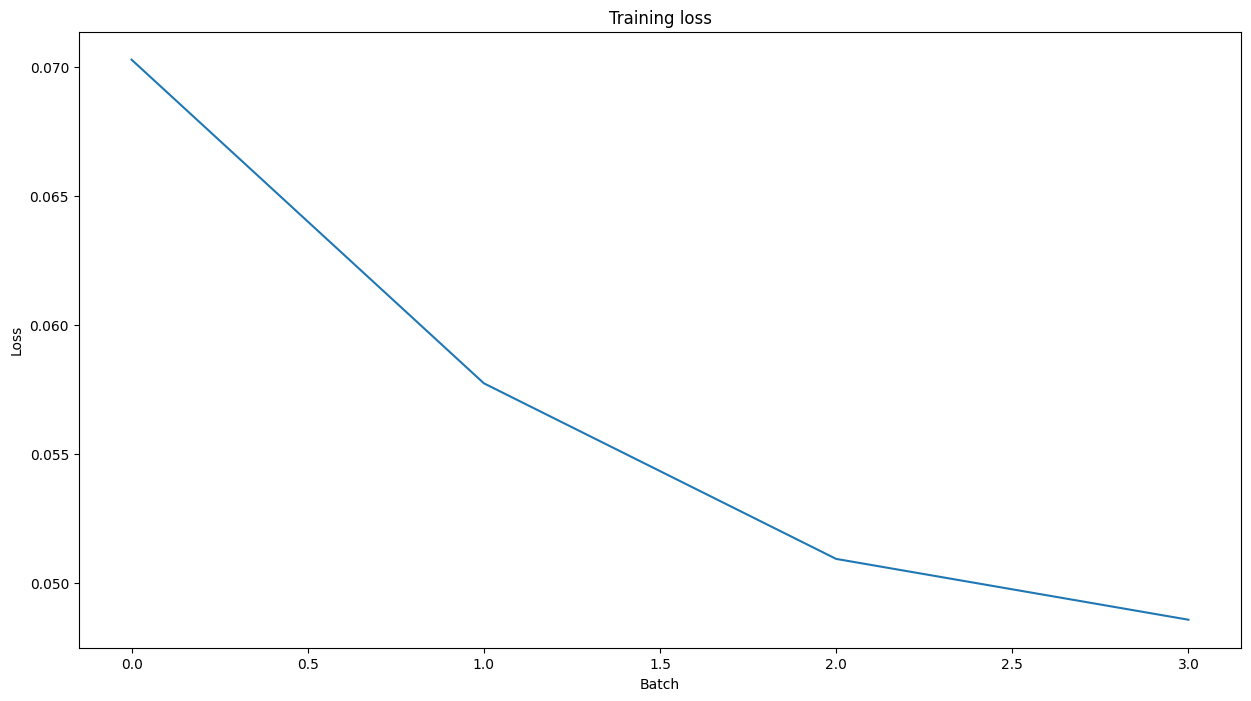

In [40]:
plt.figure(figsize=(15, 8))
plt.title("Training loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.plot(train_loss_set)
plt.show()

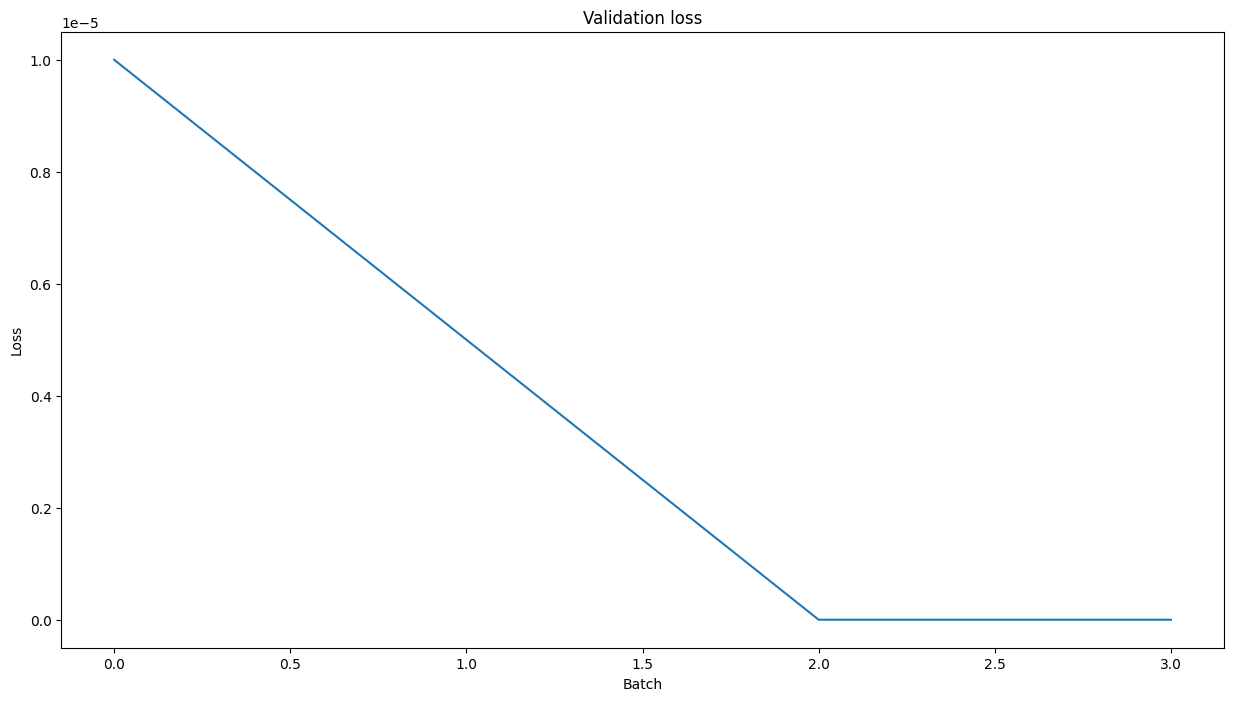

In [46]:
plt.figure(figsize=(15, 8))
plt.title("Validation loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.plot(history['learning_rates'])
plt.show()

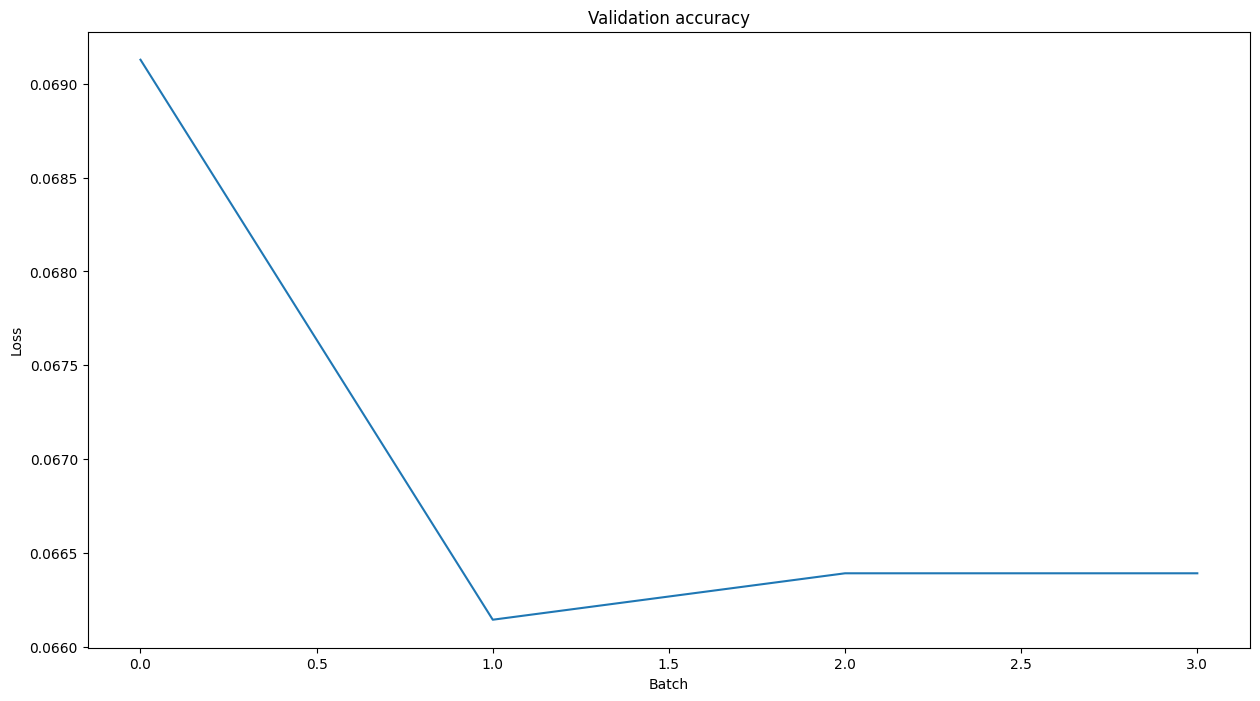

In [43]:
plt.figure(figsize=(15, 8))
plt.title("Validation accuracy")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.plot(history['val_loss'])
plt.show()

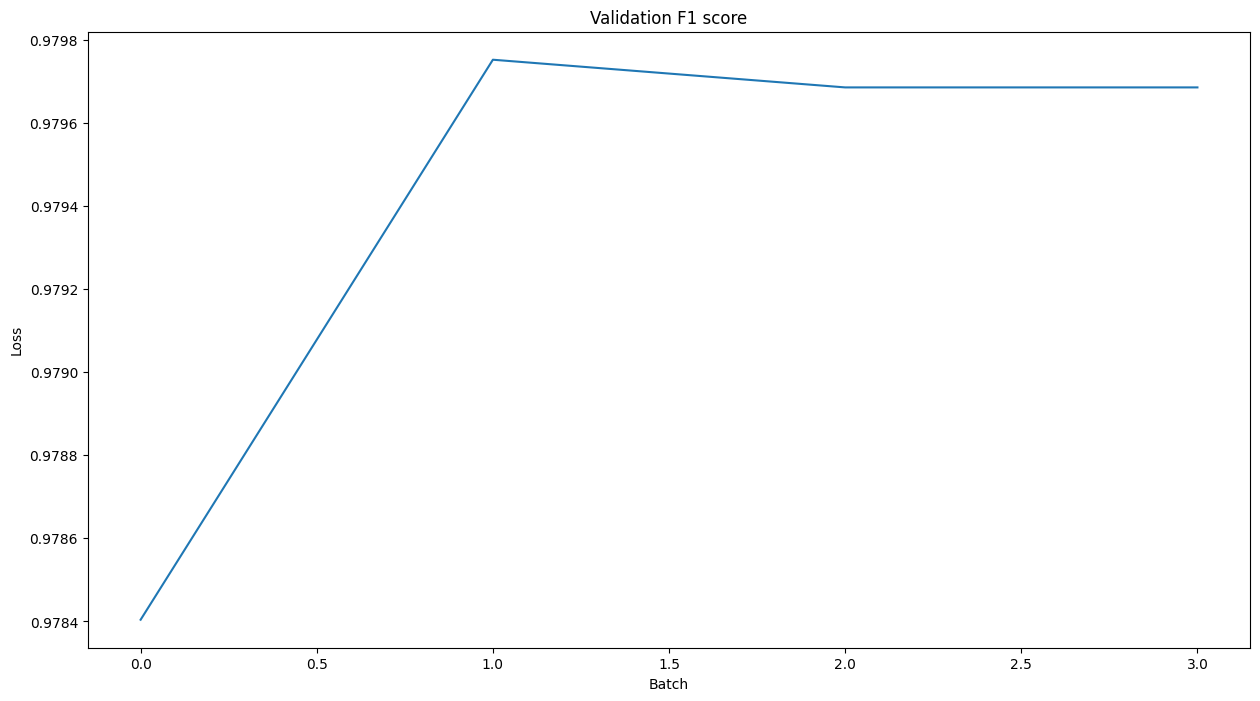

In [44]:
plt.figure(figsize=(15, 8))
plt.title("Validation F1 score")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.plot(history['val_f1'])
plt.show()

# Test

In [47]:
test_processed = processed["test"]

In [48]:
test_sampler = RandomSampler(test_processed)
test_dataloader = DataLoader(
    test_processed,
    sampler=test_sampler,
    batch_size=batch_size,
    collate_fn=data_collator,
)

In [49]:
import torch
from tqdm import tqdm

# Assicurati che il modello sia in modalità evaluation
model.eval()

# Se il modello è wrappato in DataParallel, accedi al modello base
base_model = model.module if hasattr(model, "module") else model

# Liste per salvare i risultati
all_predictions = []
all_labels = []
all_texts = []

# Disabilita il calcolo dei gradienti per velocizzare
with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Evaluating"):
        # Sposta il batch su GPU se disponibile
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Predizione
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        # Ottieni le predizioni (argmax)
        predictions = torch.argmax(outputs.logits, dim=-1)

        # Salva predizioni e label (solo dove attention_mask == 1)
        for i in range(len(predictions)):
            # Maschera per ignorare padding e token speciali
            mask = (attention_mask[i] == 1) & (labels[i] != -100)

            pred_labels = predictions[i][mask].cpu().numpy()
            true_labels = labels[i][mask].cpu().numpy()

            # Converti in nomi delle label (usa base_model invece di model)
            pred_tags = [base_model.config.id2label[p] for p in pred_labels]
            true_tags = [base_model.config.id2label[l] for l in true_labels]

            all_predictions.append(pred_tags)
            all_labels.append(true_tags)

            # Decodifica il testo originale
            tokens = tok.convert_ids_to_tokens(input_ids[i][mask].cpu().numpy())
            all_texts.append(tokens)

print(f"Data samples processed: {len(all_predictions)}")

Evaluating: 100%|██████████| 175/175 [00:29<00:00,  6.03it/s]

Data samples processed: 5594


In [50]:
from seqeval.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)

# Report
print(classification_report(all_labels, all_predictions))

# Updated metrics
print(f"\nF1 Score: {f1_score(all_labels, all_predictions):.4f}")
print(f"Precision: {precision_score(all_labels, all_predictions):.4f}")
print(f"Recall: {recall_score(all_labels, all_predictions):.4f}")

                           precision    recall  f1-score   support

              account_pin       0.55      0.78      0.65       118
                  api_key       0.81      0.81      0.81        74
      bank_routing_number       0.65      0.79      0.72       126
                     bban       0.82      0.90      0.86       135
                  company       0.73      0.87      0.80      4834
       credit_card_number       0.68      0.86      0.76        93
credit_card_security_code       0.85      0.28      0.42       105
              customer_id       0.63      0.84      0.72       171
                     date       0.75      0.83      0.79      6208
            date_of_birth       0.73      0.94      0.82       232
                date_time       0.33      0.42      0.37        77
    driver_license_number       0.69      0.83      0.75       108
                    email       0.83      0.91      0.87      1080
              employee_id       0.70      0.78      0.73     

## Tests

In [51]:
def censor_text_from_predictions(tokens, pred_tags, tokenizer):
    censored_tokens = []

    for token, tag in zip(tokens, pred_tags):
        if tag != "O":  # Se è un'entità PII
            # Censura il token
            if token.startswith("##"):
                censored_tokens.append("##" + "█" * (len(token) - 2))
            else:
                censored_tokens.append("█" * len(token))
        else:
            censored_tokens.append(token)

    # Ricostruisci la frase
    censored_text = tokenizer.convert_tokens_to_string(censored_tokens)
    return censored_text

In [110]:
import random

n = random.randint(0, len(all_texts))

original = tok.convert_tokens_to_string(all_texts[n])
censored = censor_text_from_predictions(all_texts[n], all_predictions[n], tok)

print(f"\nExample {n + 1}:")
print(100 * "-")
print(f"Original:\n{original}")
print(100 * "-")
print(f"Censored:\n{censored}")
print(100 * "-")
print(f"Entities:\n{[tag for tag in all_predictions[n] if tag != 'O']}")


Example 3294:
----------------------------------------------------------------------------------------------------
Original:
-------------------------------------------------------------------------------------------------------------------- Customer Support Conversational Log -------------------------------------------------------------------------------------------------------------------- | Timestamp | Name | Phone Number | Inquiry | Support Agent | | --- | --- | --- | --- | --- | | 2022-04-12 10:00:00 | Gavin M. Higgins | +1-407-807-5729 | Having trouble logging into the app | Agent Smith | | 2022-04-12 10:01:00 | Gavin M. Higgins | +1-407-807-5729 | | Agent Smith | | 2022-04-12 10:01:05 | Gavin M. Higgins | +1-407-807-5729 | Hi, I keep getting an error message saying "invalid credentials" even though I'm sure I'm entering the right username and password. | Agent Smith | | 2022-04-12 10:01:30 | Gavin M. Higgins | +1-407-807-5729 | I've already tried resetting my password, but it d